In [128]:
import pandas as pd
import numpy as np

In [129]:
df=pd.read_csv("Bengaluru_House_Data.csv")
df.head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [131]:
df=df.drop(["area_type","availability","society","balcony"],axis=1)
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [132]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [133]:
df["location"].value_counts()
df["location"]=df["location"].fillna("Sarjapur  Road")

In [134]:
df["location"].value_counts()

location
Whitefield                        540
Sarjapur  Road                    400
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64

In [135]:
df["size"].value_counts()
df["size"]=df["size"].fillna("2 BHK") # fill witrh the most used one or mode value
df["size"].value_counts()

size
2 BHK         5215
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
14 BHK           1
13 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [136]:
df.isnull().sum()

location       0
size           0
total_sqft     0
bath          73
price          0
dtype: int64

In [137]:
df["bath"].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9., nan,  8.,  7., 11., 10., 14.,
       27., 12., 16., 40., 15., 13., 18.])

In [138]:
df["bath"]=df["bath"].fillna(df["bath"].median())

In [139]:
df["bath"]=df["bath"].astype(int)
df["bath"].unique()

array([ 2,  5,  3,  4,  6,  1,  9,  8,  7, 11, 10, 14, 27, 12, 16, 40, 15,
       13, 18])

In [140]:
df.drop_duplicates(inplace=True)

In [141]:
df.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

# fEATURE SCALINH


In [142]:
df["location"]=df["location"].apply(lambda x:x.strip())

loc=df["location"].value_counts()
loc_less_than_10=loc[loc <=10]

df["location"]=df["location"].apply(lambda x:"others" if x in loc_less_than_10 else x)
df["location"].value_counts()

location
others                  2927
Whitefield               508
Sarjapur  Road           365
Electronic City          275
Thanisandra              226
                        ... 
Banashankari Stage V      11
Doddakallasandra          11
Kodigehalli               11
NGR Layout                11
LB Shastri Nagar          11
Name: count, Length: 232, dtype: int64

In [143]:
# handling size column

out=[int(i.split()[0]) for i in df["size"]]
df["bhk"]=out
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Uttarahalli,3 BHK,1440,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00,3
13315,Whitefield,5 Bedroom,3453,4,231.00,5
13316,others,4 BHK,3600,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2


In [144]:
df["total_sqft"].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [145]:
range_data=df[df["total_sqft"].str.contains("-",na=False)]
range_data

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4,186.000,4
56,Devanahalli,4 Bedroom,3010 - 3410,2,192.000,4
81,Hennur Road,4 Bedroom,2957 - 3450,2,224.500,4
122,Hebbal,4 BHK,3067 - 8156,4,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2,54.005,2
...,...,...,...,...,...,...
12975,Whitefield,2 BHK,850 - 1060,2,38.190,2
12990,Talaghattapura,3 BHK,1804 - 2273,3,122.000,3
13059,Harlur,2 BHK,1200 - 1470,2,72.760,2
13240,Devanahalli,1 BHK,1020 - 1130,2,52.570,1


In [146]:
df[df["total_sqft"].astype(str).str.contains("-")]

def clean_sqft(sqft):
    l=sqft.split("-")
    if len(l)==2:
        return float(l[0])+float(l[1])/2
    try:
        return float(l[0])
    except:
        return None
    
df["total_sqft"]=df["total_sqft"].apply(clean_sqft)
df["total_sqft"]=df["total_sqft"].fillna(round(df["total_sqft"].mean()))

In [147]:
#create price per sqft
#price/total_sqft

df["price_per_sqft"]=df["price"]*100000/df["total_sqft"]
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


# Handling outlier

In [150]:
df=df[df["total_sqft"]/df["bhk"]>=300]
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,11705.000000,11705.000000,11705.000000,11705.000000,11705.000000
mean,1628.246502,2.579667,114.455648,2.666809,6377.474059
std,1313.481400,1.099383,156.421987,0.995743,4291.202802
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1124.000000,2.000000,50.000000,2.000000,4207.119741
50%,1320.000000,2.000000,71.000000,3.000000,5326.086957
75%,1735.000000,3.000000,120.000000,3.000000,6989.247312
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [151]:
df=df[df["bhk"]<6]

In [152]:
df=df[df["bath"]<df["bhk"]+2]
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


In [153]:
# handling outlier in price per sqft
#sns.boxplot(x="price_per_sqft",data=df)

q1=df["price_per_sqft"].quantile(.25)
q3=df["price_per_sqft"].quantile(.75)

IQR=q3-q1

lower=q1-0.5*IQR
upper=q3+0.5*IQR

df=df[(df["price_per_sqft"]>=lower)&(df["price_per_sqft"]<=upper)]

<Axes: xlabel='price_per_sqft'>

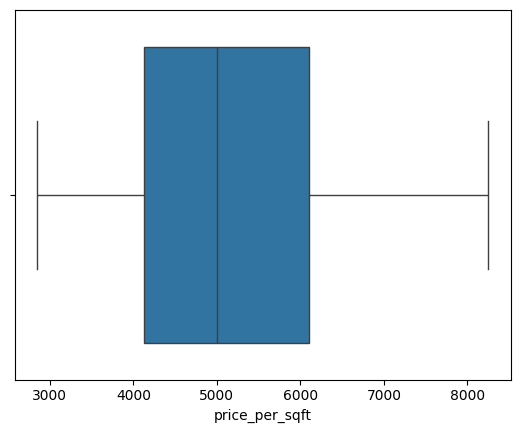

In [157]:
import seaborn as sns
sns.boxplot(x="price_per_sqft",data=df)

In [158]:
df.reset_index(inplace=True)
df=df.drop(["index","size","price_per_sqft"],axis=1)
df

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2,39.07,2
1,Chikka Tirupathi,2600.0,5,120.00,4
2,Uttarahalli,1440.0,2,62.00,3
3,Lingadheeranahalli,1521.0,3,95.00,3
4,Kothanur,1200.0,2,51.00,2
...,...,...,...,...,...
9369,Rachenahalli,1050.0,2,52.71,2
9370,Bellandur,1262.0,2,47.00,2
9371,Green Glen Layout,1715.0,3,112.00,3
9372,Whitefield,3453.0,4,231.00,5


# Training the data


In [170]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [163]:
encoder=LabelEncoder()
df["encoded_loc"]=encoder.fit_transform(df["location"])

In [165]:
x=df.drop(["location","price"],axis=1)
y=df.price

In [168]:
xtrain , xtest , ytrain , ytest = train_test_split(x , y , test_size = 0.3 , random_state = 42)

In [171]:
model=RandomForestRegressor(random_state=42)
params={
    "n_estimators":[100,150,200,250,300],
    "max_depth":[3,4,5,6,7]
}

grid=GridSearchCV(estimator=model,param_grid=params,cv=5)
grid.fit(xtrain,ytrain)

print("best param:",grid.best_params_)
print("best score:",grid.best_score_)

best param: {'max_depth': 7, 'n_estimators': 100}
best score: 0.7499135433219762


In [172]:
ypred=grid.predict(xtest)
ypred

array([44.77174385, 52.33659874, 62.83031471, ..., 48.21600919,
       56.0842407 , 46.94840626])

In [176]:
print(grid.score(xtrain,ytrain))
print(grid.score(xtest,ytest))

0.8753006749162202
0.8398155384012614


In [177]:
from sklearn.metrics import r2_score,mean_absolute_error
print("r2:",r2_score(ytest,ypred))
print("MAE:",mean_absolute_error(ytest,ypred))

r2: 0.8398155384012614
MAE: 14.430824234158386


In [178]:
df.to_csv("cleaned_df.csv")
df

,location,total_sqft,bath,price,bhk,encoded_loc
0,Electronic City Phase II,1056.0,2,39.07,2,75
1,Chikka Tirupathi,2600.0,5,120.00,4,57
2,Uttarahalli,1440.0,2,62.00,3,216
3,Lingadheeranahalli,1521.0,3,95.00,3,154
4,Kothanur,1200.0,2,51.00,2,146
...,...,...,...,...,...,...
9369,Rachenahalli,1050.0,2,52.71,2,183
9370,Bellandur,1262.0,2,47.00,2,40
9371,Green Glen Layout,1715.0,3,112.00,3,83
9372,Whitefield,3453.0,4,231.00,5,224


In [179]:
import pickle
with open("RF_model.pkl","wb") as file:
    pickle.dump(grid,file)